# SINDy prediction of the collected data 

# Load your necessary libraries for running the code

In [1]:
import numpy as np
import pysindy as ps
from scipy.io import loadmat
from pysindy.differentiation import SmoothedFiniteDifference
from pysindy.differentiation import FiniteDifference
from pysindy.feature_library import polynomial_library
from pysindy.feature_library import custom_library
from pysindy.feature_library import ConcatLibrary
from pysindy.feature_library import identity_library

from sklearn.metrics import mean_squared_error
# from scipy.integrate import solve_ivp
# from scipy.integrate import odeint

# %matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.cm import rainbow

# Integrating the velocity dataset

(125001, 1)
(125001, 1)
(125001, 1)


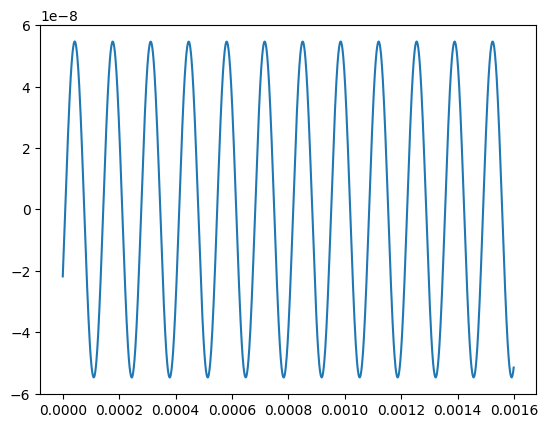

In [3]:
from scipy.integrate import simpson

rec_time = 0.1
#rec_time = 60
sampling_rate = 1250000
start_time = 0
t_array = np.arange(start_time, rec_time, 1/sampling_rate)
t_array = np.array(t_array)
t_array = t_array[:,np.newaxis]

velocity_dataset = loadmat("datasel_7422Hz_Sin_800mSrec_4-40kHzfilter_0.449mA_pointfromtip_2.mat")
velocity_raw  = velocity_dataset["datasel"]
velocity = velocity_raw[:, 1]
velocity = np.array(velocity)
velocity = velocity[:,np.newaxis]


#displacement = simpson(velocity, t_array)
def calculate_displacement(velocity, sampling_rate):
    displacement_initial = []
    for i in range(len(velocity)):
        displacement = velocity[i] * (1/sampling_rate)
        displacement_initial = np.append(displacement_initial, displacement)
    
    return displacement_initial

displacement_initial = calculate_displacement(velocity, sampling_rate)

displacement = np.array(displacement_initial)
displacement = displacement[:,np.newaxis]

print(displacement.shape)
print(velocity.shape)
print(t_array.shape) 

#plt.plot(velocity)
plt.plot(t_array[:2000, 0], displacement[:2000, 0])

# Saving integrated dataset to a text file

In [4]:
np.savetxt('integrated displacement for 0.449mA', displacement) 

# Loading the data

In [5]:
# Time base for displacement dataset
rec_time = 0.1
sampling_rate = 1250000

# # Time base for voltage dataset
# rec_time = 10
# sampling_rate = 96000

start_time = 0
t_array = np.arange(start_time, rec_time, 1/sampling_rate)
t_array = np.array(t_array)
t_array= t_array[:,np.newaxis]

# # Loading voltage dataset
# data_file = loadmat("10filtered_700_13000.mat")
# read_out_raw = data_file["low_filtered"]

# # Creating voltage training dataset 
# x_rec = read_out_raw[196001:200001]
# t_train = t_array[196001:200001]

# Creating displacement training dataset 
x_rec = displacement[46001:52001]
t_train = t_array[46001:52001]

print(t_train.shape)
print(x_rec.shape)
# print(data_file)
print(t_array.shape)
print(displacement.shape)

(6000, 1)
(6000, 1)
(125001, 1)
(125001, 1)


# Smooth the Data and Decompose the assumed 2nd order ODE system into two first order ODE 
Smoothing is being performed via Savgol Golay filter which performs a moving 3rd order polynomial approximation on the dataset. The optimized window length for displacement and volatge datasetare 5 and 11. The centered finite difference scheme is then employed to perform the differentiation.

(6000, 3)
(6000, 1)
(6000, 1)


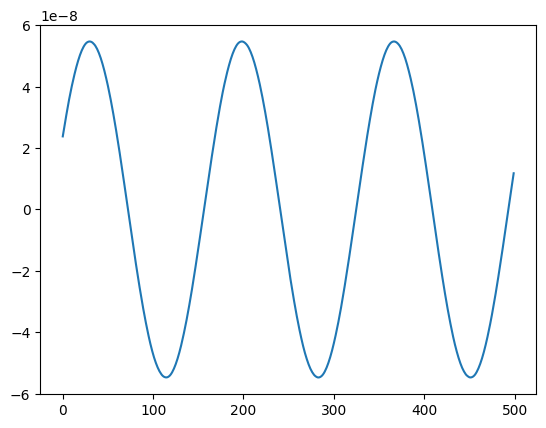

In [6]:
#Trying out different differentiators

#x_rec =np.abs(signal_filtered)
#fd = FiniteDifference(drop_endpoints=True)
sfd = SmoothedFiniteDifference(smoother_kws={'window_length': 5} )
#sfd = SmoothedFiniteDifference()
#diff = ps.SINDyDerivative(kind="trend_filtered", order=1, alpha=1e-3)

#xdot = fd._differentiate(x_rec, t_train)
xdot = sfd._differentiate(x_rec, t_train[:, 0])
#xdot = diff._differentiate(x_rec,t_train)

# Here dataset is being prepared for feeding to SINDy with which SINDy knows that we are loooking for a 2nd order ODE. 
data_x_train = np.hstack((x_rec, xdot, t_train))

print(data_x_train.shape)
print(t_train.shape)
print(xdot.shape)
plt.plot(x_rec [:500, 0])

# Train the model and build the necessary library to represent the dynamics of your system
Generalized Library is being used as a final model while the disussed high bias + variance model is also listed. The model needs the exact frequencies of the higher harmonics. This is preferred to make a cost-efficient model, as otherwise SINDy has to find 5 driving force terms (till 5th higher harmonics) from 38000 terms, implying a rigorous thresholding and regularization. Also the stiffness and damping terms are customed with the same argument.

1.(a): Polynomial+ Fourier Library

In [8]:
""" poly_order = 1
max_iter = 10000

#for STLSQ
threshold = 0.3  # optimized value = 0.3 if polyorder=1
regularization_on_weight = 0.09    # default is 0.05

#variable thresholding for SR3 optimizers
thresholds = 0.05* np.ones((5, 2))
thresholds[2:, :] = 0.1  #  Determines the strength of the regularization. When the regularization function R is the L0 norm, the regularization is equivalent to performing hard thresholding, and lambda is chosen to threshold at the value given by this parameter. This is equivalent to choosing lambda = threshold^2 / (2 * nu).
nu = 2 #Determines the level of relaxation. Decreasing nu encourages w and v to be close, whereas increasing nu allows the regularized coefficients v to be farther from w.
tol = 0.00001 #for determining convergence

#sr3 = ps.SR3(thresholder="weighted_l0", thresholds=thresholds, max_iter=max_iter, nu=nu, tol=tol)
stlsq =ps.STLSQ(alpha=regularization_on_weight, threshold=threshold, max_iter=max_iter)

lib_poly = ps.feature_library.PolynomialLibrary(degree = poly_order)
lib_fourier = ps.feature_library.FourierLibrary(n_frequencies = 1, include_sin=False, include_cos=True)

functions = [lambda x:x,
             lambda x,y : np.cos(x * y)
]
function_names = [lambda x : x,
                  lambda x,y : 'cos(' + x +', ' + y +')'
    
]
lib_custom = ps.CustomLibrary(library_functions = functions, function_names=function_names)

model_sine=ps.SINDy(
    optimizer=stlsq,
    #optimizer=sr3,
    differentiation_method= sfd,
    feature_names=["x", "xdot"],
    discrete_time=False,
    feature_library=ps.feature_library.ConcatLibrary([lib_poly, lib_fourier])
    )

model_sine.fit(data_x_train, 1/sampling_rate)
model_sine.print()
model_sine.get_feature_names() """

(x)' = 1.000 xdot
(xdot)' = -1122841.793 1 + -2173836879.325 x + -1.324 xdot + 1390158.087 cos(1 x) + -486671.766 cos(1 xdot)


['1', 'x', 'xdot', 'cos(1 x)', 'cos(1 xdot)']

1(b) Generalized Library

In [7]:
import numpy as np

poly_order = 3
max_iter = 10

# for STLSQ
regularization_on_weight = 0.05
threshold = 0.2

#variable thresholding for SR3 optimizers
# thresholds = 0.05* np.ones((11, 3))
# thresholds[2 :, :] = 0.5
# nu = 0.3
# tol= 0.00001

#ensemble_optimizer = ps.EnsembleOptimizer(ps.STLSQ(threshold=threshold, alpha=regularization_on_weight, normalize_columns=False, max_iter=max_iter), bagging=True, replace=False, n_subset=1000, n_models=6, ensemble_aggregator=np.median)
stlsq = ps.STLSQ(threshold=threshold, max_iter=max_iter, alpha=regularization_on_weight)
#sr3 = ps.SR3(thresholder="weighted_l0", thresholds=thresholds, max_iter=max_iter, nu=nu, tol=tol)

#Initialize Libraries

#lib_poly = ps.feature_library.PolynomialLibrary(degree = poly_order, include_interaction=False, include_bias=False)

#lib_fourier = ps.feature_library.FourierLibrary(n_frequencies = 1, include_cos=False, include_sin=True)

funct = [lambda x : x,
         lambda x : x ** 3 ,
         #lambda x,y : (x* y)
        ]

names = [lambda x : '(' + x + ')',
         lambda x : '(' + x + '^' '3' ')',
         #lambda x, y : '(' + x + '*' + y + ')'
         ]
lib_xdot = ps.CustomLibrary(library_functions=funct, function_names=names)

lib_id = ps.IdentityLibrary()

# For displacement dataset
functions = [lambda x :  np.cos(x * 7420),
            lambda x :  np.cos(x * 14840),
            lambda x :  np.cos(x * 22270),
            lambda x :  np.cos(x * 29680),
            lambda x :  np.cos(x * 37090),
            # lambda x :  np.cos(x * 9648),
            # lambda x :  np.cos(x * 10389),
            # lambda x :  np.cos(x * 11880),
            # lambda x :  np.cos(x * 13362),
            # lambda x :  np.cos(x * 14095),
            # lambda x :  np.cos(x * 14837),
            ]

function_names = [lambda x : 'cos(' + x + '*' '7420' ')',
                  lambda x : 'cos(' + x + '*' '14840' ')',
                  lambda x : 'cos(' + x + '*' '22270' ')',
                  lambda x : 'cos(' + x + '*' '29680' ')',
                  lambda x : 'cos(' + x + '*' '37090' ')',
                #   lambda x : 'cos(' '12590', '*', + x + ')',
                #   lambda x : 'cos(' '15100', '*', + x+ ')'
                    ]
# # For voltage dataset
# functions = [lambda x :  np.cos(x * 2517),
#              lambda x :  np.cos(x * 5034),
#              lambda x :  np.cos(x * 7551),
#              lambda x :  np.cos(x * 10068),
#              lambda x :  np.cos(x * 12585)
#             ]
# function_names = [lambda x : 'cos(' + x + '*' '2517' ')',
#                   lambda x : 'cos(' + x + '*' '5034' ')',
#                   lambda x : 'cos(' + x + '*' '7551' ')',
#                   lambda x : 'cos(' + x + '*' '10068' ')',
#                   lambda x : 'cos(' + x + '*' '12585' ')'
#                  ]  

lib_custom = ps.CustomLibrary(library_functions=functions, function_names=function_names)
 
inputs_per_library = [[0, 0, 1],  [2, 2, 2]]

inputs_per_library = np.reshape(inputs_per_library, (2, 3))

# Tensor all the polynomial and Fourier library terms together
tensor_array = [[0, 1, 1]]

generalized_library = ps.GeneralizedLibrary([lib_xdot, lib_custom], 
                                            #tensor_array=tensor_array,
                                            #exclude_libraries=[1],
                                            inputs_per_library=inputs_per_library)
# Lets define model architecture 
model_sine=ps.SINDy(
    optimizer=stlsq,
    #optimizer=ensemble_optimizer,
    #optimizer=sr3,
    differentiation_method= sfd,
    feature_names=["x", "xdot", "t"],
    discrete_time=False,
    feature_library=generalized_library
    
    )
# Lets train the model
model_sine.fit(data_x_train, 1/sampling_rate)

# See the discovered equation and the used features, i.e., the candidate terms
model_sine.print(lhs=['dx/dt', 'd(xdot)/dt', 'dt/dt'])
model_sine.get_feature_names()

dx/dt = 1.000 (xdot)
d(xdot)/dt = -2174198397.354 (x) + -2.490 (xdot) + 0.012 cos(t*7420) + -0.002 cos(t*14840) + -0.014 cos(t*22270) + -0.018 cos(t*29680) + -0.013 cos(t*37090)
dt/dt = -4.753 (xdot)


['(x)',
 '(xdot)',
 '(x^3)',
 '(xdot^3)',
 'cos(t*7420)',
 'cos(t*14840)',
 'cos(t*22270)',
 'cos(t*29680)',
 'cos(t*37090)']

# Defining validation and Test_set to evaluate model stability

In [8]:
#validation 100001:103001. test_set varies (102k-105k)
x_test = displacement[100001:103001]
t_test = t_array[100001:103001]
# t_test = np.array(t_test)
# t_test = t_test[:,np.newaxis]

xdot_test = sfd._differentiate(x_test, t_test[:, 0])
data_x_train_test = np.hstack((x_test, xdot_test, t_test))
print(data_x_train_test.shape)

(3000, 3)


Now , Simulate the discovered model forward in time providing the initial condition.

In [10]:
# #Training evaluation 
# sim = model_sine.simulate(np.array(data_x_train[0]), t_train[:,0]) 

#Model stability evaluation
sim = model_sine.simulate(np.array(data_x_train_test[0]), t_test[:,0]) 

sim.shape
#sim_noisy.shape

(3000, 3)

# Evaluating error and R2_score

In [11]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# # R2_score_train = r2_score(data_x_train[:, 1], sim[:, 1])
# # R2_score_train = "{:.3f}".format(R2_score_train)
# Pearson_correlation_train = pearsonr(data_x_train[:, 0], sim[:, 0])
# Pearson_correlation_train_noisy = pearsonr(data_x_train_noisy[:, 0], sim_noisy[:, 0])
# Pearson_correlation_train = "{:.3f}".format(Pearson_correlation_train[0])

# #print(f"The observed R2_score for the training_set is:",R2_score_train)
# print(f"The Pearson_correlation for the training_set is :", Pearson_correlation_train)
# print(f"The Pearson_correlation for the noisy training_set is :", Pearson_correlation_train_noisy)

R2_score_test = r2_score(data_x_train_test[:, 0], sim[:, 0])
R2_score_test = "{:.3f}".format(R2_score_test)
Pearson_correlation_test = pearsonr(data_x_train_test[0:, 0], sim[:, 0])
Pearson_correlation_test = "{:.3f}".format(Pearson_correlation_test[0])

print(f"The observed R2_score for the validation set is:",R2_score_test)
print(f"The Pearson_correlation for the validation set is :", Pearson_correlation_test )

The observed R2_score for the validation set is: 1.000
The Pearson_correlation for the validation set is : 1.000


# Plotting the evaluation

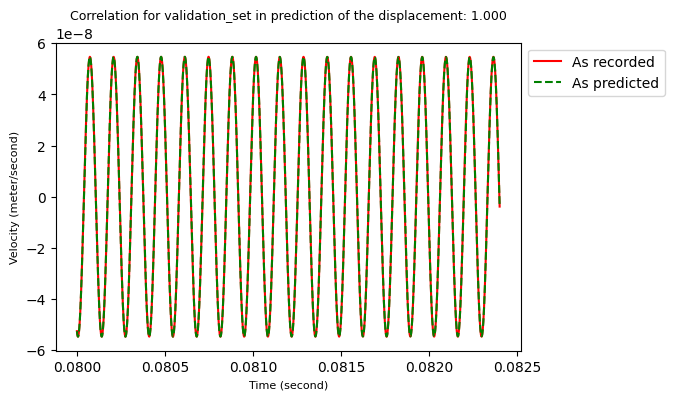

In [12]:
fig,ax = plt.subplots(1,1, figsize=(6,4))
#ax.set_ylabel('Displacement (meter)', fontsize=8)
ax.set_ylabel('Velocity (meter/second)', fontsize=8)
ax.set_xlabel('Time (second)', fontsize=8)

# #ax.set_title(f'R2_score for training is : {R2_score_train} ')
# ax.set_title(f'Correlation for training_set in prediction of the velocity: : {Pearson_correlation_train}',fontsize=9)

# plt.plot( t_train[0:1000 ,0], data_x_train[0:1000, 0], 'r', label="As recorded")
# plt.plot( t_train[0:1000, 0], sim[0:1000, 0], 'g-.',  label="As predicted")
# plt.plot( t_train[0:1000, 0], sim_noisy[0:1000, 0], 'y-.',  label="As predicted")
# plt.plot( t_train[0:1000 ,0], data_x_train_noisy[0:1000, 0], 'b', label="As recorded")

#ax.set_title(f'R2_score for validation_set is : {R2_score_test} ')
ax.set_title(f'Correlation for validation_set in prediction of the displacement: {Pearson_correlation_test}', fontsize=9)

plt.plot( t_test[0:, 0], data_x_train_test[0:, 0], 'r', label="As recorded")
plt.plot( t_test[0:, 0], sim[0:, 0], 'g--',  label="As predicted")

ax.legend(loc='upper left',  bbox_to_anchor=(1.0005, 1))

#  Optimizing the hyperparameters. 
The SINDy has 4 hyperparameters: Threshold , regularization strength (alpha),  window length,  and the total number of epochs (has almost no effect due to the library settings). The optimization scheme is shown for the threshold value which is to be repeated for all the hyperparameters.

In [13]:
# Make coefficient plot for threshold scan
def plot_pareto(coefs, opt, model, threshold_scan, x_test, t_test):
    dt = 1/sampling_rate
    mse = np.zeros(len(threshold_scan))
    mse_sim = np.zeros(len(threshold_scan))
    for i in range(len(threshold_scan)):
        opt.coef_ = coefs[i]
        mse[i] = model.score(x_test, t=dt, metric=mean_squared_error)
        x_test_sim = model.simulate(x_test[0], t_test[:,0], integrator="odeint")
        # if np.any(x_test_sim > 1e4):
        #     x_test_sim = 1e4
        mse_sim[i] = np.sum((x_test[:,0] - x_test_sim[:, 0]) ** 2)
    
    plt.figure()
    plt.semilogy(threshold_scan, mse, "ro")
    plt.semilogy(threshold_scan, mse, "g")
    plt.title(" Effect of threshold value on xdot")
    plt.ylabel(r"$\dot{X}$ RMSE", fontsize=20)
    plt.xlabel(r"threshold values", fontsize=20)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)
    
    plt.figure()
    plt.semilogy(threshold_scan, mse_sim, "yo")
    plt.semilogy(threshold_scan, mse_sim, "b")
    plt.title(" Effect of threshold value on simulated xdot")
    plt.ylabel(r"$\dot{X}$ RMSE", fontsize=20)
    plt.xlabel(r"threshold values", fontsize=20)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)

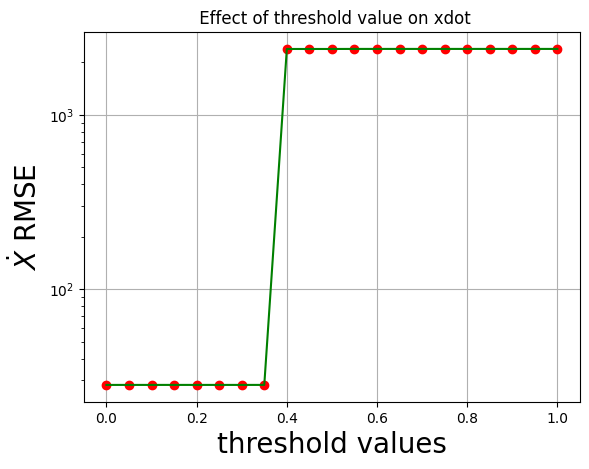

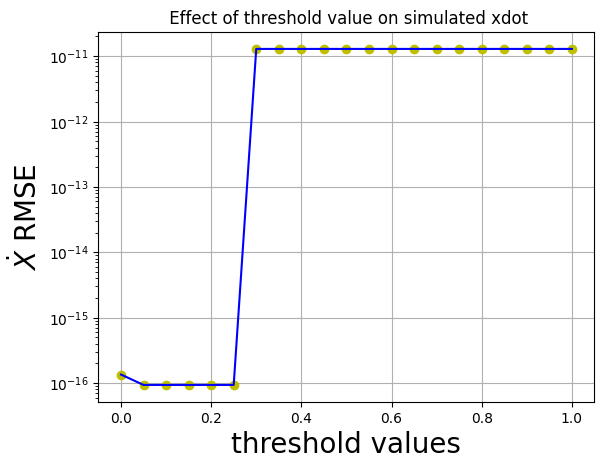

In [14]:
threshold_scan = np.arange(0.0, 1.05, 0.05)
coefs = []
rmse = mean_squared_error(data_x_train, np.zeros(data_x_train.shape), squared=False)

#x_train_added_noise = x_train + np.random.normal(0, rmse / 10.0,  x_train.shape)

for i, threshold in enumerate(threshold_scan):
    sparse_regression_optimizer = ps.STLSQ(threshold=threshold)
    model_sine = ps.SINDy(
    optimizer=sparse_regression_optimizer,
    #optimizer=sr3,
    differentiation_method= sfd,
    feature_names=["x", "xdot", "t"],
    discrete_time=False,
    feature_library=generalized_library
    )
    model_sine.fit(data_x_train, 1/sampling_rate, quiet=True)
    #model_sine.fit(data_x_train, 1/sampling_rate, ensemble=True, replace=False, n_subset=1000, n_models=3, quiet=True, unbias=False, ensemble_aggregator=np.median)
    coefs.append(model_sine.coefficients())

plot_pareto(coefs, sparse_regression_optimizer, model_sine,
            threshold_scan, data_x_train_test, t_test)

# Finding best dataset fragment for training and validation.
Only shown for the displacement dataset which is also the same approach for the voltage dataset.

In [ ]:
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

window_size = 6000
start_indices = np.arange(40001, 100001, window_size)  # Start indices for each portion
t_array_new = t_array
errors = []
errors_p = []
for start_index in start_indices:
    end_index = start_index + window_size
    portion_sig =displacement[start_index:end_index]
    portion_time = t_array_new[start_index:end_index]
    portion_xdot = sfd._differentiate(portion_sig, portion_time[:, 0] )
    data_x_train_new = np.hstack((portion_sig, portion_xdot, portion_time))
    model_sine=ps.SINDy(
    optimizer=stlsq,
    #optimizer=ensemble_optimizer,
    #optimizer=sr3,
    differentiation_method= sfd,
    # differentiation_method=diff,
    feature_names=["x", "xdot", "t"],
    discrete_time=False,
    feature_library=generalized_library 
    )
    model_sine.fit(data_x_train_new, 1/sampling_rate)
    
    sim_new = model_sine.simulate(np.array(data_x_train_new[0]), portion_time[:, 0], integrator="odeint") 
    # Calculate and store the error metrics of each portion

    error = r2_score(data_x_train_new[:, 0], sim_new[:, 0])
    error_p = pearsonr(data_x_train_new[:, 0], sim_new[:, 0])
    errors.append(error)
    errors_p.append(error_p)
    
    print(f"Start index: {start_index}, Error: {error, error_p}")

C:\Users\sayee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pysindy\optimizers\stlsq.py:201: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


Start index: 40001, Error: (0.9992330642196365, PearsonRResult(statistic=0.9996351824167145, pvalue=0.0))
Start index: 46001, Error: (0.9997055492430533, PearsonRResult(statistic=0.999883048897795, pvalue=0.0))
Start index: 52001, Error: (0.9994377528550097, PearsonRResult(statistic=0.9997270550311737, pvalue=0.0))
Start index: 58001, Error: (0.9994589033897884, PearsonRResult(statistic=0.9997486047414729, pvalue=0.0))


C:\Users\sayee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pysindy\optimizers\stlsq.py:201: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


Start index: 64001, Error: (0.9993396044297567, PearsonRResult(statistic=0.9996703728496846, pvalue=0.0))
Start index: 70001, Error: (0.9992610576811749, PearsonRResult(statistic=0.9996452696510575, pvalue=0.0))
Start index: 76001, Error: (0.9995059943014621, PearsonRResult(statistic=0.9997535442982066, pvalue=0.0))
Start index: 82001, Error: (0.9995589987768059, PearsonRResult(statistic=0.9997972298872866, pvalue=0.0))
Start index: 88001, Error: (0.9993920233643153, PearsonRResult(statistic=0.9996975380082962, pvalue=0.0))
Start index: 94001, Error: (0.9995293344935087, PearsonRResult(statistic=0.9997657266652691, pvalue=0.0))


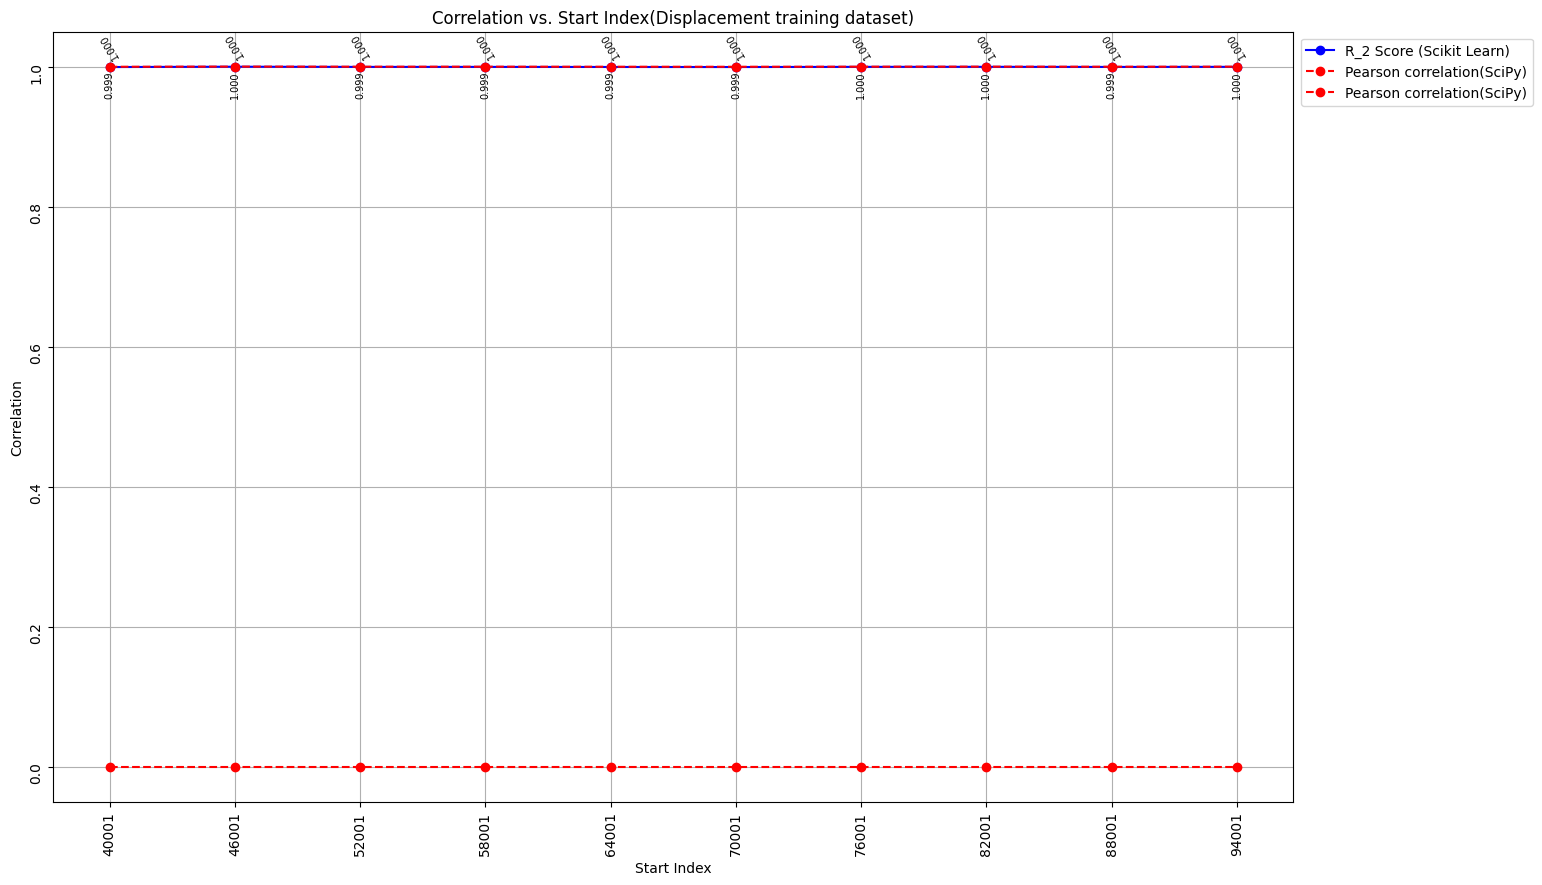

In [54]:
#from matplotlib.offsetbox import offset_copy
# Plotting the errors
plt.figure(figsize=(16, 10))
plt.xlabel('Start Index')
#plt.ylim(0.8, 1)
plt.ylabel('Correlation')
plt.title('Correlation vs. Start Index(Displacement training dataset)', loc='center')
plt.xticks(start_indices, fontsize=10, rotation=90)
plt.yticks(fontsize=10, rotation=90)

# Plot the configurations and scores
plt.plot(start_indices, errors, marker='o', linestyle='-', color='b', label="R_2 Score (Scikit Learn)")
plt.plot(start_indices, errors_p, marker='o', linestyle='--', color='r', label="Pearson correlation(SciPy)")

plt.grid(True)

plt.legend(loc='upper left',  bbox_to_anchor=(1.0005, 1))

for x, score in zip(start_indices, errors):
    score_value = score
    text = "{:.3f}".format(score_value)
    text_y = score_value - 0.0055  # Adjust the y-coordinate for positioning
    plt.text(x, text_y, text, ha='center', va='top', fontsize=7, rotation=90)


for x, corr in zip(start_indices, errors_p):
    corr_value = corr[0]  # Extract the first value (correlation)
    text = "{:.3f}".format(corr_value)
    text_y = corr_value + 0.01  # Adjust the y-coordinate for positioning
    plt.text(x, text_y, text, ha='center', va='bottom', fontsize=7, rotation=120)
plt.show()

In [55]:
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

window_size =3000
start_indices = np.arange(100001, 112001, window_size)  # Start indices for each portion
errors = []
errors_p = []
for start_index in start_indices:
    end_index = start_index + window_size
    portion_sig = displacement[start_index:end_index]
    portion_time = t_array_new[start_index:end_index]
    portion_xdot = sfd._differentiate(portion_sig, portion_time [:, 0])
    data_x_train_new = np.hstack((portion_sig, portion_xdot, portion_time))

    
    sim_new = model_sine.simulate(np.array(data_x_train_new[0]), portion_time[:, 0], integrator="odeint") 
    # Calculate and store the error metrics of each portion

    error = r2_score(data_x_train_new[:, 0], sim_new[:, 0])
    error_p = pearsonr(data_x_train_new[:, 0], sim_new[:, 0])
    errors.append(error)
    errors_p.append(error_p)
    
    print(f"Start index: {start_index}, Error: {error, error_p}")

Start index: 100001, Error: (0.9999026706808244, PearsonRResult(statistic=0.9999580558378267, pvalue=0.0))
Start index: 103001, Error: (0.9998165946192397, PearsonRResult(statistic=0.9999084043268103, pvalue=0.0))
Start index: 106001, Error: (0.9997331300961592, PearsonRResult(statistic=0.9998668912609125, pvalue=0.0))
Start index: 109001, Error: (0.9997494118952186, PearsonRResult(statistic=0.9998878145987523, pvalue=0.0))


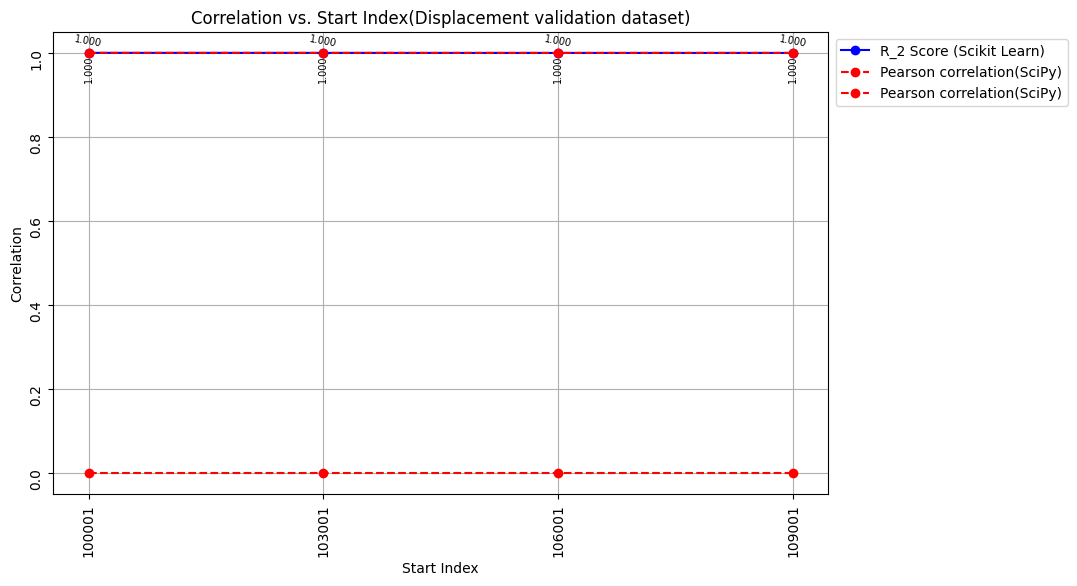

In [56]:
#from matplotlib.offsetbox import offset_copy
# Plotting the errors
plt.figure(figsize=(10, 6))
plt.xlabel('Start Index')
#plt.ylim(0.8, 1)
plt.ylabel('Correlation')
plt.title('Correlation vs. Start Index(Displacement validation dataset)', loc='center')
plt.xticks(start_indices, fontsize=10, rotation=90)
plt.yticks(fontsize=10, rotation=90)

# Plot the configurations and scores
plt.plot(start_indices, errors, marker='o', linestyle='-', color='b', label="R_2 Score (Scikit Learn)")
plt.plot(start_indices, errors_p, marker='o', linestyle='--', color='r', label="Pearson correlation(SciPy)")

plt.grid(True)

plt.legend(loc='upper left',  bbox_to_anchor=(1.0005, 1))

for x, score in zip(start_indices, errors):
    score_value = score
    text = "{:.3f}".format(score_value)
    text_y = score_value - 0.0055  # Adjust the y-coordinate for positioning
    plt.text(x, text_y, text, ha='center', va='top', fontsize=7, rotation=90)


for x, corr in zip(start_indices, errors_p):
    corr_value = corr[0]  # Extract the first value (correlation)
    text = "{:.3f}".format(corr_value)
    text_y = corr_value + 0.01  # Adjust the y-coordinate for positioning
    plt.text(x, text_y, text, ha='center', va='bottom', fontsize=7, rotation=-10)
plt.show()

# Exemplary analysis of the discovered duffing system.
Due to better resolution MATLAB was employed for the plot of the different post-analysis which are included in the report. Here, only the phase portrait of the displacement dataset is shown.

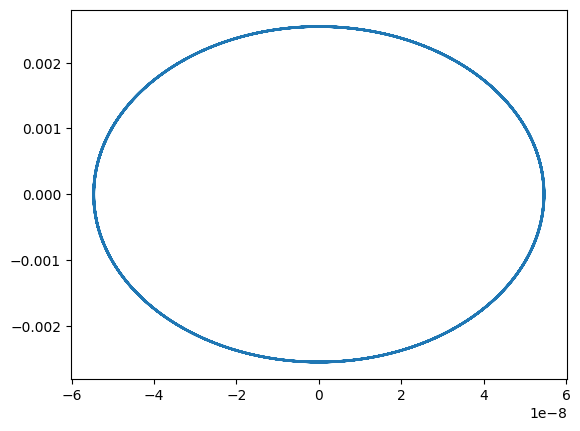

In [15]:
plt.plot(sim[:, 0], sim[:, 1])